In [1]:
pip install shap

Note: you may need to restart the kernel to use updated packages.


In [2]:
import shap

print(shap.__version__)

0.52.0


In [3]:
import shap
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
model = joblib.load("yield_prediction_model.pkl")

print(type(model))

<class 'sklearn.ensemble._forest.RandomForestRegressor'>


In [5]:
df = pd.read_csv("data/CropYield/yield_df.csv")

df.drop("Unnamed: 0", axis=1, inplace=True)

In [6]:
from sklearn.preprocessing import LabelEncoder

area_encoder = LabelEncoder()
item_encoder = LabelEncoder()

df["Area"] = area_encoder.fit_transform(df["Area"])
df["Item"] = item_encoder.fit_transform(df["Item"])

In [7]:
X = df.drop("hg/ha_yield", axis=1)
y = df["hg/ha_yield"]

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [9]:
X_sample = X_test.sample(n=500, random_state=42)

explainer = shap.Explainer(model)

shap_values = explainer(
    X_sample,
    check_additivity=False
)

print(type(shap_values))
print(shap_values.values.shape)

<class 'shap._explanation.Explanation'>
(500, 6)


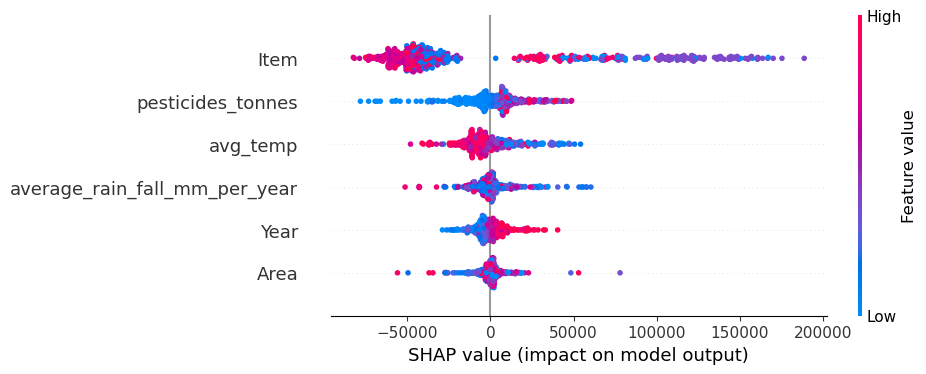

In [10]:
# SHAP Beeswarm Plot
shap.plots.beeswarm(
    shap_values,
    max_display=6,
    show=False
)

plt.savefig(
    "SHAP_Beeswarm.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

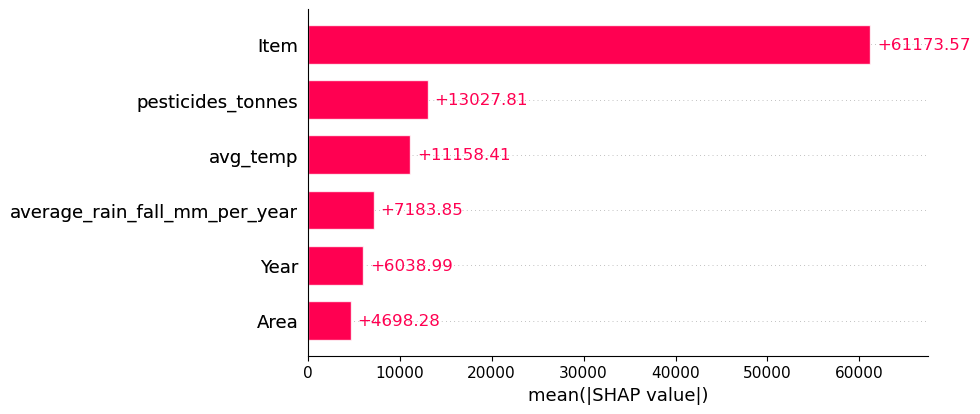

In [11]:
# SHAP Feature Importance Bar Plot

shap.plots.bar(
    shap_values,
    max_display=6,
    show=False
)

plt.savefig(
    "SHAP_Bar.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

In [12]:
# SHAP Waterfall Plot
import numpy as np

predictions = model.predict(X_sample)

highest_index = np.argmax(predictions)

print("Highest Predicted Yield:", predictions[highest_index])

Highest Predicted Yield: 441627.82


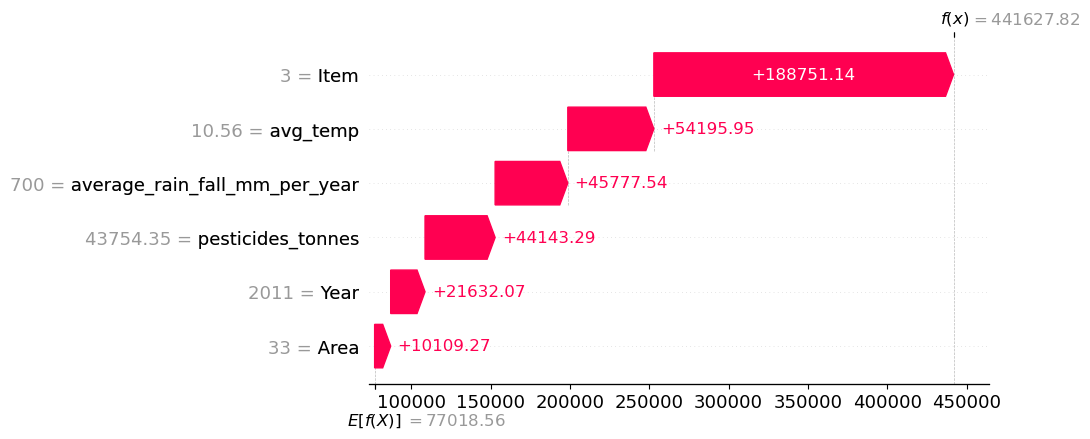

In [13]:
shap.plots.waterfall(
    shap_values[highest_index],
    show=False
)

plt.savefig(
    "SHAP_Waterfall.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

## Summary

1. The saved Random Forest crop yield prediction model was loaded for explainability analysis.

2. SHAP (SHapley Additive exPlanations) was used to interpret the model's predictions.

3. A SHAP Explainer was created to calculate feature contributions for prediction outcomes.

4. A SHAP Beeswarm Plot was generated to visualize both the magnitude and direction of each feature's impact on crop yield predictions.

5. A SHAP Global Feature Importance Bar Plot ranked all input features according to their overall contribution to the model.

6. A SHAP Waterfall Plot was generated for an individual sample to explain how each feature influenced a specific crop yield prediction.

7. The Explainable AI analysis improved the transparency and interpretability of the Random Forest model, making its predictions easier to understand and validate.